In [50]:
import torch
import pickle
import time
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils import BoxUniform
import argparse
import sbibm
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import sys
sys.path.append('..')
from inference_utils import get_prior
import numpy as np

from collective_posterior import CollectivePosterior

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize


# inferences = []
# for i in range(10):
#     inferences.append(pickle.load(open(f'posterior_{i+1}.pkl', 'rb')))


# task = sbibm.get_task("slcp")
# prior = task.get_prior_dist()
# simulator = task.get_simulator()


In [53]:
def WF(parameters, seed=None):
    """ CNV evolution simulator
    Simulates CNV and SNV evolution for x generations
    Returns proportion of the population with a CNV for specific generations
    
    Parameters
    -------------------
    N : int = 10M
        population size  
    s_snv : float
        fitness benefit of SNVs  
    m_snv : float 
        probability mutation to SNV   
    generation : np.array, 1d 
        with generations to output
    seed : int
    
    s_cnv : float
        fitness benefit of CNVs  
    m_cnv : float 
        probability mutation to CNV 
    p_0: float
        fraction of population with GAP1 CNV before beginning of experiment
    """
    # CNV parameters
    s_cnv, m_cnv, p_0 = 10**parameters

    # SNV parameters as constants
    s_snv = 1e-3
    m_snv = 1e-5
    N = 1e6
    generation = np.array([8, 21, 29, 37, 50, 58, 66, 79, 87, 95, 108, 116]) # from Chuong et al 2025
    
    if seed is not None:
        np.random.seed(seed=seed)
    else:
        np.random.seed()

    
    
    
    # Order is: wt, cnv+, cnv-, snv
    
    w = np.array([1, 1 + s_cnv, 1 + s_cnv, 1 + s_snv], dtype='float64')
    S = np.diag(w)
    
    # make transition rate array
    M = np.array([[1 - m_cnv - m_snv, 0, 0, 0],
                [m_cnv, 1, 0, 0],
                [0, 0, 1, 0],
                [m_snv, 0, 0, 1]], dtype='float64')
    assert np.allclose(M.sum(axis=0), 1)
    
    
    # mutation and selection
    E = M @ S

    # rows are genotypes, p has proportions after initial (unreported) growth
    n = np.zeros(4)
    n[2] = N*p_0 # cnv-
    n[0] = N*(1-p_0) # wt
    
    # follow proportion of the population with CNV
    # here rows will be generation, columns (there is only one) is replicate population
    p_cnv = []
    
    # run simulation to generation 116
    for t in range(int(generation.max()+1)):    
        p = n/N  # counts to frequencies
        p_cnv.append(p[1])  # frequency of reported CNVs
        p = E @ p.reshape((4, 1))  # natural selection + mutation        
        p /= p.sum()  # rescale proportions
        n = np.random.multinomial(N, np.ndarray.flatten(p)) # random genetic drift
    ret = np.transpose(p_cnv)[generation.astype(int)]
    noise = np.random.normal(0,0.02,size=ret.shape)
    return torch.tensor(ret + noise)

prior = get_prior('WF')
simulator = WF
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)

In [61]:
num_sim = 100

# Ensemble of 10 NPEs on the same simulation set
inferences = []
for i in range(10):
    # inference
    # Check prior, return PyTorch prior.
    prior, num_parameters, prior_returns_numpy = process_prior(prior)
    theta = prior.sample((num_sim,))
    # Check simulator, returns PyTorch simulator able to simulate batches.
    simulator = process_simulator(simulator, prior, prior_returns_numpy)
    theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=num_sim)
    inference = NPE(prior)
    density_estimator = inference.append_simulations(theta, x).train(max_num_epochs=100)
    posterior = inference.build_posterior(density_estimator)
    inferences.append(posterior)

# Save the posterior with pickle
for i, posterior in enumerate(inferences):
    with open(f'posterior_{i+1}_b.pkl', 'wb') as f:
        pickle.dump(posterior, f)


  0%|          | 0/100 [00:00<?, ?it/s]

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [3]:
from sbi.inference import EnsemblePosterior
inferences = [pickle.load(open(f'posterior_{i+1}_b.pkl', 'rb')) for i in range(10)]
ensemble_posterior = EnsemblePosterior(inferences)

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Drawing 104 posterior samples:   0%|          | 0/104 [00:00<?, ?it/s]

Drawing 103 posterior samples:   0%|          | 0/103 [00:00<?, ?it/s]

Drawing 96 posterior samples:   0%|          | 0/96 [00:00<?, ?it/s]

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
Rejection Sampling: 1292it [00:02, 459.47it/s]                                  
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seabor

Text(0.5, 0, '$\\varphi$')

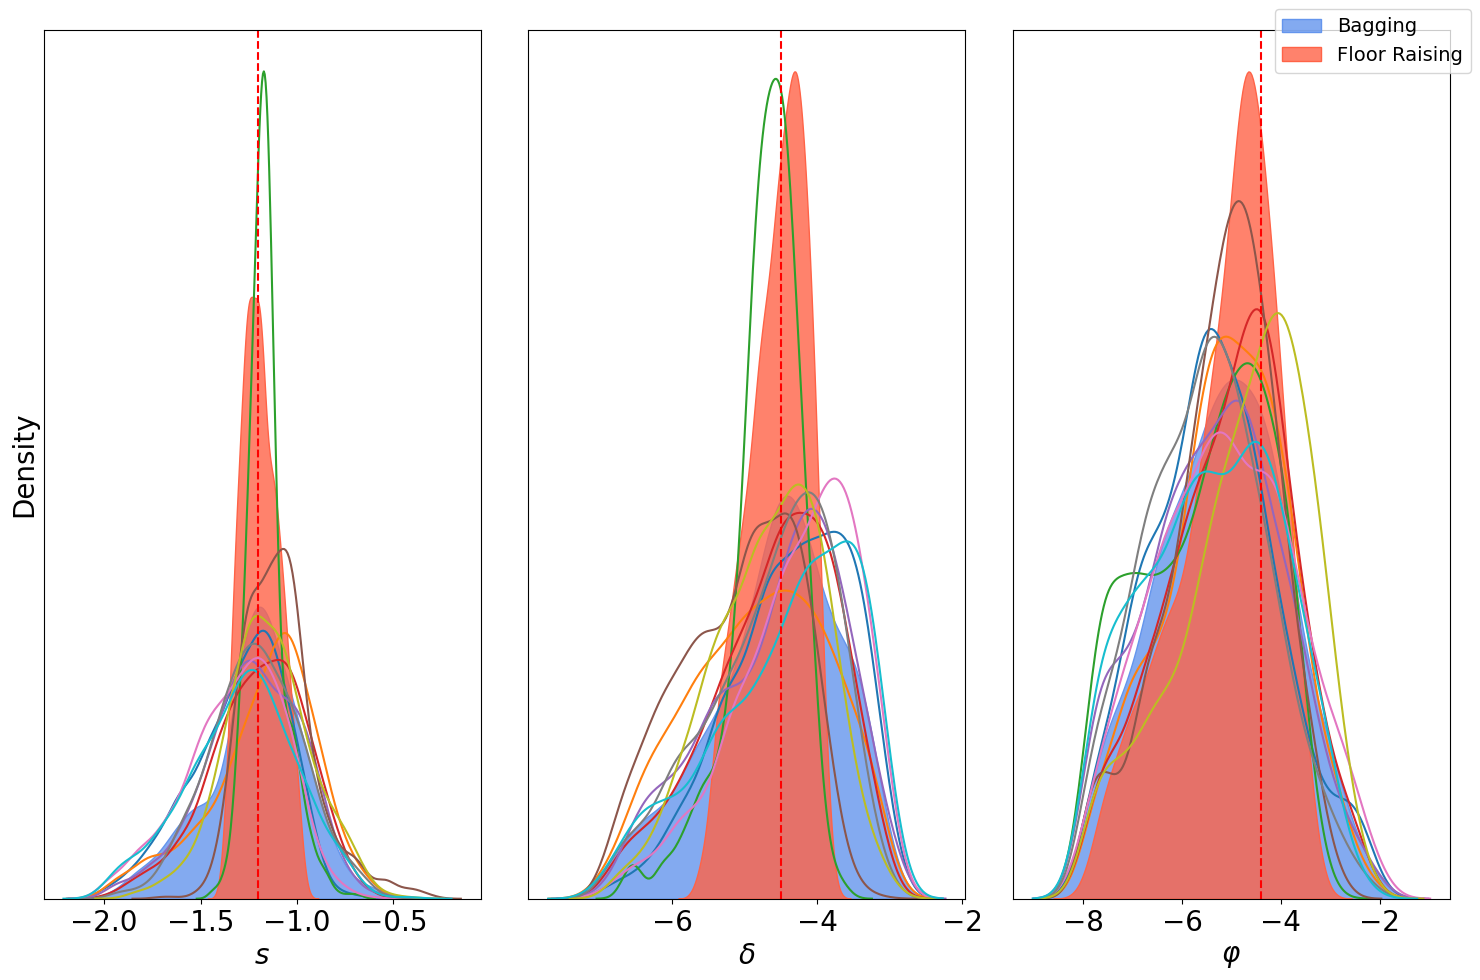

In [4]:
from seaborn import kdeplot
import matplotlib.pyplot as plt
th = torch.tensor([[-1.2, -4.5, -4.4]])
x_ = simulator(th)
def plot_samples(samples, ax, color=None, label=None, fill=False, alpha=1.0):
    for i in range(len(samples[0])):
        if color is not None:
            kdeplot(samples[:,i].numpy(), ax=ax[i], color=color, label=label if i==0 else None, fill=fill, alpha=alpha)
        else:
            kdeplot(samples[:,i].numpy(), ax=ax[i], label=label if i==0 else None, fill=fill, alpha=alpha)
    plt.setp(ax, yticks=[])

change_font(20)
fig, ax = plt.subplots(1,3, figsize=(15,10), tight_layout=True)
for i in range(10):
    samples = inferences[i].set_default_x(x_).sample((1000,))
    plot_samples(samples, ax, label = None)
for i in range(len(th[0])):
    ax[i].axvline(th[0][i].item(), color='r', linestyle='--')
samples = ensemble_posterior.set_default_x(x_).sample((1000,))
plot_samples(samples, ax, color='cornflowerblue', label='Bagging', fill=True, alpha=0.8)
cp = CollectivePosterior(prior, Xs=[x_ for i in range(len(inferences))], posterior_list=[inference.set_default_x(x_).log_prob for inference in inferences], epsilon=-10000, log_C=1)
cp.get_log_C()
samples = cp.rejection_sample(1000)
plot_samples(samples, ax, color='tomato', label='Floor Raising', fill=True, alpha=0.8)
fig.legend(fontsize=14)
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[0].set_xlabel('$s$')
ax[1].set_xlabel('$\\delta$')
ax[2].set_xlabel('$\\varphi$')


In [7]:
# test set
num_sim = 200
prior = get_prior('WF')
simulator = WF

prior, num_parameters, prior_returns_numpy = process_prior(prior)
theta = prior.sample((num_sim,))
# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(simulator, prior, prior_returns_numpy)
theta_test, x_test = simulate_for_sbi(simulator, proposal=prior, num_simulations=num_sim)



  0%|          | 0/200 [00:00<?, ?it/s]

In [27]:
# evaluate ensembles (bagging vs. floor raising)

conf_levels = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95]
def coverage_old(posterior, samples, conf_levels, theta):
    covs = torch.empty(len(conf_levels), len(theta))
    for j in range(len(conf_levels)):
        conf_level = conf_levels[j]   
        taken_samples = samples[:int(conf_level*len(samples))+1]
        hdi = [torch.quantile(samples, (1-conf_level)/2, 0), torch.quantile(samples,(1+conf_level)/2, 0)]
        covs[j,:] = ((theta > hdi[0])*(theta < hdi[1]))
    
    return covs


def evaluate(posterior, thetas, Xs, n_samples, cp = False):
    accus = torch.empty(thetas.shape)
    covs = torch.empty(len(thetas[:,0]),len(conf_levels), len(thetas[0]))
    all_samples = torch.empty(len(thetas), n_samples, len(thetas[0]))
    for i in range(len(thetas)):
        th = thetas[i]
        x = Xs[i]
        if cp:
            cp = CollectivePosterior(prior, Xs=[x_ for i in range(len(inferences))], 
                                     posterior_list=[inference.set_default_x(x_).log_prob for inference in posterior],
                                     log_C=1, n_eval=10_000, epsilon=-10000)
            cp.get_log_C()
            samples = cp.rejection_sample(n_samples)
        else:
            samples = posterior.set_default_x(x).sample((n_samples,))
        all_samples[i,:,:] = samples
        params = torch.tensor(th, dtype=torch.float32)
        accus[i] = samples.mean(0)-params
        covs[i] = coverage_old(posterior, samples, conf_levels, theta=th)
        if i%10 == 9:
            print(f'{round(100*(i+1)/len(thetas),2)}%')
    return accus, covs, all_samples


In [12]:
accus, covs, all_samples = evaluate(posterior, theta_test, x_test, n_samples=1000)
torch.save(accus, 'accus_bagging.pt')
torch.save(covs, 'covs_bagging.pt')
torch.save(all_samples, 'samples_bagging.pt')

Drawing 117 posterior samples:   0%|          | 0/117 [00:00<?, ?it/s]

Drawing 93 posterior samples:   0%|          | 0/93 [00:00<?, ?it/s]

Drawing 89 posterior samples:   0%|          | 0/89 [00:00<?, ?it/s]

Drawing 105 posterior samples:   0%|          | 0/105 [00:00<?, ?it/s]

Drawing 109 posterior samples:   0%|          | 0/109 [00:00<?, ?it/s]

...

Drawing 93 posterior samples:   0%|          | 0/93 [00:00<?, ?it/s]

Drawing 99 posterior samples:   0%|          | 0/99 [00:00<?, ?it/s]

Drawing 99 posterior samples:   0%|          | 0/99 [00:00<?, ?it/s]

Drawing 108 posterior samples:   0%|          | 0/108 [00:00<?, ?it/s]

100.0%


In [29]:
accus, covs, all_samples = evaluate(inferences, theta_test, x_test, n_samples=1000, cp=True)
torch.save(accus, 'accus_fr.pt')
torch.save(covs, 'covs_fr.pt')
torch.save(all_samples, 'samples_fr.pt')

Rejection Sampling: 1239it [00:05, 235.73it/s]                                  
/tmp/ipykernel_301313/1805928460.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  params = torch.tensor(th, dtype=torch.float32)
Rejection Sampling: 1283it [00:04, 264.99it/s]                                  
Rejection Sampling: 1192it [00:05, 222.64it/s]                                  
Rejection Sampling: 1332it [00:04, 268.03it/s]                                  
Rejection Sampling: 1310it [00:05, 233.42it/s]                                  
Rejection Sampling: 1184it [00:05, 203.05it/s]                                  
Rejection Sampling: 1030it [00:04, 248.43it/s]                                  
Rejection Sampling: 1268it [00:05, 243.22it/s]                                  
Rejection Sampling: 1005it [00:03, 262.45it/s]                     

5.0%


Rejection Sampling: 1242it [00:05, 219.65it/s]                                  
Rejection Sampling: 1277it [00:05, 244.64it/s]                                  
Rejection Sampling: 1227it [00:05, 218.65it/s]                                  
Rejection Sampling: 1169it [00:05, 222.19it/s]                                  
Rejection Sampling: 1212it [00:05, 205.71it/s]                                  
Rejection Sampling: 1263it [00:05, 242.25it/s]                                  
Rejection Sampling: 1203it [00:06, 198.39it/s]                                  
Rejection Sampling: 1305it [00:04, 271.76it/s]                                  
Rejection Sampling: 1223it [00:05, 240.38it/s]                                  
Rejection Sampling: 1272it [00:05, 243.48it/s]                                  


10.0%


Rejection Sampling: 1252it [00:05, 230.36it/s]                                  
Rejection Sampling: 1271it [00:04, 269.58it/s]                                  
Rejection Sampling: 1254it [00:05, 224.01it/s]                                  
Rejection Sampling: 1237it [00:04, 267.40it/s]                                  
Rejection Sampling: 1303it [00:05, 233.52it/s]                                  
Rejection Sampling: 1196it [00:05, 230.22it/s]                                  
Rejection Sampling: 1210it [00:05, 231.55it/s]                                  
Rejection Sampling: 1223it [00:05, 234.56it/s]                                  
Rejection Sampling: 1190it [00:05, 214.18it/s]                                  
Rejection Sampling: 1183it [00:05, 204.61it/s]                                  


...

90.0%


Rejection Sampling: 1314it [00:05, 261.22it/s]                                  
Rejection Sampling: 1273it [00:06, 208.99it/s]                                  
Rejection Sampling: 1239it [00:05, 221.92it/s]                                  
Rejection Sampling: 1214it [00:05, 241.26it/s]                                  
Rejection Sampling: 1264it [00:05, 223.27it/s]                                  
Rejection Sampling: 1246it [00:05, 218.43it/s]                                  
Rejection Sampling: 1189it [00:05, 216.09it/s]                                  
Rejection Sampling: 1171it [00:04, 238.90it/s]                                  
Rejection Sampling: 1331it [00:05, 249.56it/s]                                  
Rejection Sampling: 1188it [00:06, 191.98it/s]                                  


95.0%


Rejection Sampling: 1178it [00:05, 211.98it/s]                                  
Rejection Sampling: 1314it [00:05, 239.65it/s]                                  
Rejection Sampling: 1149it [00:05, 216.95it/s]                                  
Rejection Sampling: 1244it [00:05, 228.14it/s]                                  
Rejection Sampling: 1174it [00:05, 214.01it/s]                                  
Rejection Sampling: 1002it [00:03, 290.61it/s]                                  
Rejection Sampling: 1352it [00:05, 232.03it/s]                                  
Rejection Sampling: 1291it [00:04, 260.23it/s]                                  
Rejection Sampling: 1252it [00:05, 239.20it/s]                                  
Rejection Sampling: 1200it [00:05, 227.43it/s]                                  

100.0%


In [35]:
num_sim = 10000
task = sbibm.get_task('slcp')
prior = task.get_prior_dist()
simulator = task.get_simulator()

# Ensemble of 10 NPEs on the same simulation set
inferences = []
for i in range(10):
    # inference
    # Check prior, return PyTorch prior.
#     prior, num_parameters, prior_returns_numpy = process_prior(prior)
#     theta = prior.sample((num_sim,))
#     # Check simulator, returns PyTorch simulator able to simulate batches.
#     simulator = process_simulator(simulator, prior, prior_returns_numpy)
#     theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=num_sim)

#     inference = NPE(prior)
#     density_estimator = inference.append_simulations(theta, x).train(max_num_epochs=100)
#     posterior = inference.build_posterior(density_estimator)
    theta = prior.sample((num_sim,))
    x = simulator(theta)

    inference = NPE(prior)
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=100)
    posterior = inference.build_posterior()
    inferences.append(posterior)

# Save the posterior with pickle
for i, posterior in enumerate(inferences):
    with open(f'slcp_posterior_{i+1}_b.pkl', 'wb') as f:
        pickle.dump(posterior, f)


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn